In [ ]:
from google.colab import files
uploaded = files.upload()

Saving accepted_2007_to_2018Q4.csv.gz to accepted_2007_to_2018Q4.csv.gz


In [ ]:
!pip install shap --quiet

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, classification_report,
                             RocCurveDisplay)
from sklearn.preprocessing import LabelEncoder

print("ready")

ready


In [ ]:
# 100k rows — manageable size
df = pd.read_csv('accepted_2007_to_2018Q4.csv.gz',
                 compression='gzip',
                 low_memory=False,
                 nrows=100000)

print(f"Loaded: {df.shape[0]:,} rows and {df.shape[1]} columns")
df.head(3)

Loaded: 100,000 rows and 151 columns


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Only keep completed loans (remove loans still being repaid)
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])]

# 1 = default, 0 = paid
df['default'] = (df['loan_status'] == 'Charged Off').astype(int)

print(f"Loans after filtering: {df.shape[0]:,}")
print(f"Default rate: {df['default'].mean():.1%}")

Loans after filtering: 87,891
Default rate: 20.0%


In [46]:
# standard credit risk variables
numeric_features = [
    'loan_amnt',
    'int_rate',            # lender's own risk signal
    'installment',
    'annual_inc',
    'dti',                 # key ratio
    'delinq_2yrs',
    'fico_range_low',
    'open_acc',
    'pub_rec',
    'revol_util',
    'total_acc',
    'mort_acc',
    'pub_rec_bankruptcies'
]

# added categoricals
categorical_features = [
    'home_ownership',      # own/rent/mortgage
    'purpose',             # loan purpose
    'emp_length'           # stability signal
]


df_cats = df[categorical_features + ['default']].copy()
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in categorical_features:
    df_cats[col] = df_cats[col].fillna('unknown')
    df_cats[col] = le.fit_transform(df_cats[col])

df_numeric = df[numeric_features + ['default']].copy()

df_model = pd.concat([df_numeric, df_cats[categorical_features]], axis=1)
df_model.dropna(inplace=True)

features = numeric_features + categorical_features

print(f"final: {df_model.shape[0]:,} rows, {len(features)} features")
print(f"default rate: {df_model['default'].mean():.1%}")
df_model.describe().round(2)

final: 87,853 rows, 16 features
default rate: 20.0%


,loan_amnt,int_rate,installment,annual_inc,dti,delinq_2yrs,fico_range_low,open_acc,pub_rec,revol_util,total_acc,mort_acc,pub_rec_bankruptcies,default,home_ownership,purpose,emp_length
count,87853.00,87853.00,87853.00,87853.00,87853.00,87853.00,87853.00,87853.00,87853.00,87853.00,87853.00,87853.00,87853.00,87853.0,87853.00,87853.00,87853.00
mean,14377.07,11.95,429.83,77679.61,18.99,0.35,694.52,11.86,0.25,51.63,25.16,1.64,0.14,0.2,1.91,2.40,4.11
std,8595.06,4.13,253.68,89683.86,9.70,0.93,31.11,5.66,0.72,24.13,12.15,1.94,0.39,0.4,0.94,1.94,3.62
min,1000.00,5.32,14.77,1200.00,0.00,0.00,660.00,1.00,0.00,0.00,4.00,0.00,0.00,0.0,0.00,0.00,0.00
25%,7925.00,8.49,244.97,46000.00,12.32,0.00,670.00,8.00,0.00,33.50,16.00,0.00,0.00,0.0,1.00,1.00,1.00
50%,12000.00,11.53,369.93,65000.00,18.41,0.00,685.00,11.00,0.00,51.40,23.00,1.00,0.00,0.0,2.00,2.00,3.00
75%,20000.00,14.33,572.19,92557.00,25.21,0.00,710.00,15.00,0.00,69.90,32.00,3.00,0.00,0.0,3.00,2.00,7.00
max,35000.00,28.99,1354.66,9000000.00,999.00,30.00,845.00,67.00,86.00,152.50,135.00,35.00,8.00,1.0,3.00,11.00,11.00


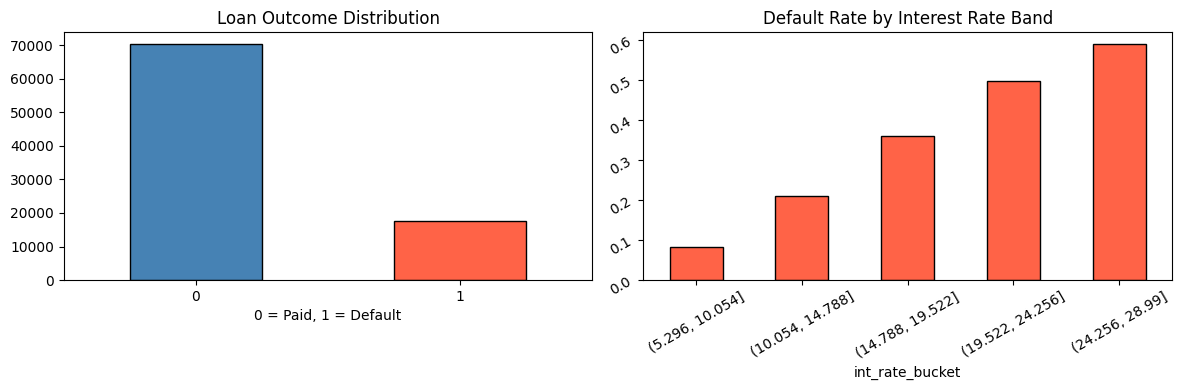

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Chart 1: Distribution of defaults vs paid
df_model['default'].value_counts().plot(kind='bar', ax=axes[0],
    color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Loan Outcome Distribution')
axes[0].set_xlabel('0 = Paid, 1 = Default')
axes[0].tick_params(rotation=0)

# Chart 2: Rate predicts default?
df_model['int_rate_bucket'] = pd.cut(df_model['int_rate'], bins=5)
df_model.groupby('int_rate_bucket')['default'].mean().plot(
    kind='bar', ax=axes[1], color='tomato', edgecolor='black')
axes[1].set_title('Default Rate by Interest Rate Band')
axes[1].tick_params(rotation=30)

plt.tight_layout()
plt.savefig('eda_charts.png', bbox_inches='tight', dpi=150)
plt.show()

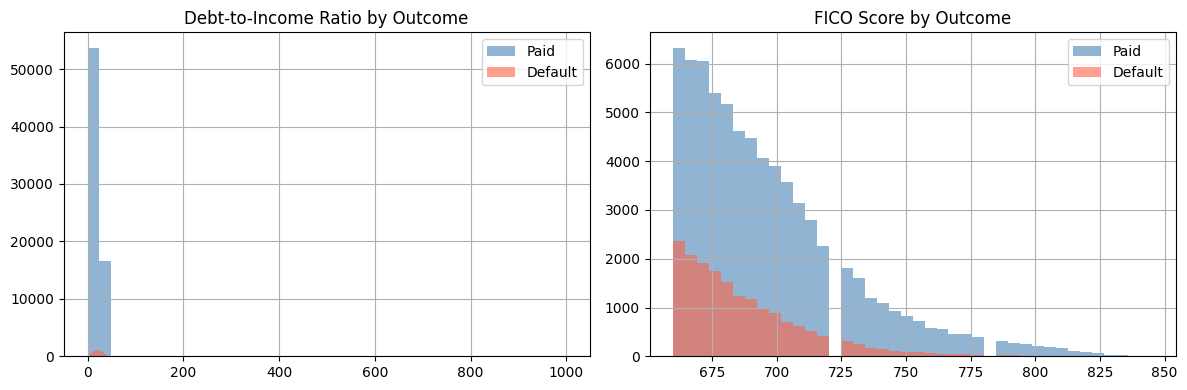

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# DTI ratio by outcome — higher DTI = more likely to default
df_model[df_model['default']==0]['dti'].hist(ax=axes[0], alpha=0.6,
    color='steelblue', bins=40, label='Paid')
df_model[df_model['default']==1]['dti'].hist(ax=axes[0], alpha=0.6,
    color='tomato', bins=40, label='Default')
axes[0].set_title('Debt-to-Income Ratio by Outcome')
axes[0].legend()

# FICO score by outcome — lower FICO = more likely to default
df_model[df_model['default']==0]['fico_range_low'].hist(ax=axes[1], alpha=0.6,
    color='steelblue', bins=40, label='Paid')
df_model[df_model['default']==1]['fico_range_low'].hist(ax=axes[1], alpha=0.6,
    color='tomato', bins=40, label='Default')
axes[1].set_title('FICO Score by Outcome')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_distributions.png', bbox_inches='tight', dpi=150)
plt.show()

In [49]:
X = df_model[features]
y = df_model['default']

# keep same default rate in both splits
# reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")
print(f"Default rate — Train: {y_train.mean():.1%} | Test: {y_test.mean():.1%}")

Training: 70,282 | Test: 17,571
Default rate — Train: 20.0% | Test: 20.0%


In [50]:
# corrects for imbalance
# otherwise, predicts "paid" every time
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_model.fit(X_train, y_train)

lr_proba = lr_model.predict_proba(X_test)[:, 1]
lr_preds = lr_model.predict(X_test)
lr_auc = roc_auc_score(y_test, lr_proba)

print(f"Logistic Regression — ROC-AUC: {lr_auc:.4f}")
print(classification_report(y_test, lr_preds, target_names=['Paid', 'Default']))

Logistic Regression — ROC-AUC: 0.7413
              precision    recall  f1-score   support

        Paid       0.89      0.70      0.78     14052
     Default       0.35      0.65      0.46      3519

    accuracy                           0.69     17571
   macro avg       0.62      0.68      0.62     17571
weighted avg       0.78      0.69      0.72     17571



In [51]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,             # cap depth — overfitting risk
    class_weight='balanced',  # imbalance
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

rf_proba = rf_model.predict_proba(X_test)[:, 1]
rf_preds = rf_model.predict(X_test)
rf_auc = roc_auc_score(y_test, rf_proba)

print(f"Random Forest — ROC-AUC: {rf_auc:.4f}")
print(classification_report(y_test, rf_preds, target_names=['Paid', 'Default']))

Random Forest — ROC-AUC: 0.7390
              precision    recall  f1-score   support

        Paid       0.89      0.71      0.79     14052
     Default       0.35      0.63      0.45      3519

    accuracy                           0.69     17571
   macro avg       0.62      0.67      0.62     17571
weighted avg       0.78      0.69      0.72     17571



In [52]:
# xgb imbalance correction
scale = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,        # step size
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='auc',
    verbosity=0
)
xgb_model.fit(X_train, y_train)

xgb_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_preds = xgb_model.predict(X_test)
xgb_auc = roc_auc_score(y_test, xgb_proba)

print(f"XGBoost — ROC-AUC: {xgb_auc:.4f}")
print(classification_report(y_test, xgb_preds, target_names=['Paid', 'Default']))

XGBoost — ROC-AUC: 0.7420
              precision    recall  f1-score   support

        Paid       0.89      0.70      0.78     14052
     Default       0.35      0.65      0.46      3519

    accuracy                           0.69     17571
   macro avg       0.62      0.67      0.62     17571
weighted avg       0.78      0.69      0.72     17571



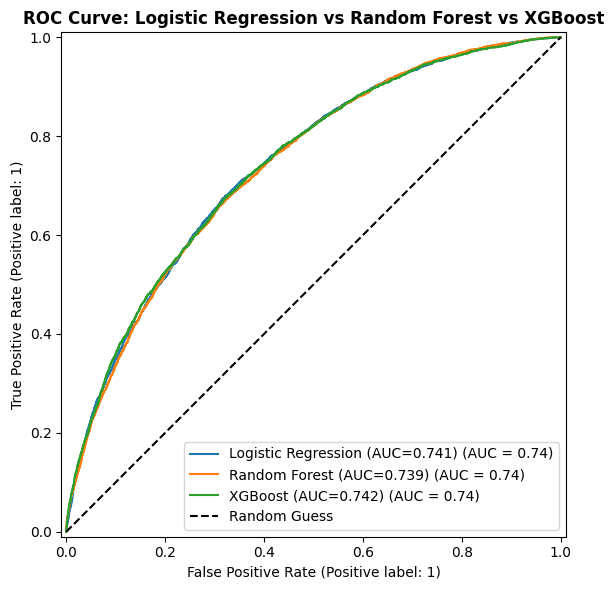

              Model    AUC       Type
            XGBoost 0.7420 Non-Linear
Logistic Regression 0.7413     Linear
      Random Forest 0.7390 Non-Linear


In [53]:
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(y_test, lr_proba,
    name=f'Logistic Regression (AUC={lr_auc:.3f})', ax=ax)
RocCurveDisplay.from_predictions(y_test, rf_proba,
    name=f'Random Forest (AUC={rf_auc:.3f})', ax=ax)
RocCurveDisplay.from_predictions(y_test, xgb_proba,
    name=f'XGBoost (AUC={xgb_auc:.3f})', ax=ax)

ax.plot([0,1],[0,1],'k--', label='Random Guess')
ax.set_title('ROC Curve: Logistic Regression vs Random Forest vs XGBoost', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curves.png', bbox_inches='tight', dpi=150)
plt.show()

# compare all three
results = pd.DataFrame({'Model':['Logistic Regression','Random Forest','XGBoost'],
    'AUC':[round(lr_auc,4),round(rf_auc,4),round(xgb_auc,4)],
    'Type':['Linear','Non-Linear','Non-Linear']})
print(results.sort_values('AUC', ascending=False).to_string(index=False))

In [54]:
# subset — shap is slow on full test set
X_test_sample = X_test.sample(500, random_state=42)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_sample)
print("done")

done


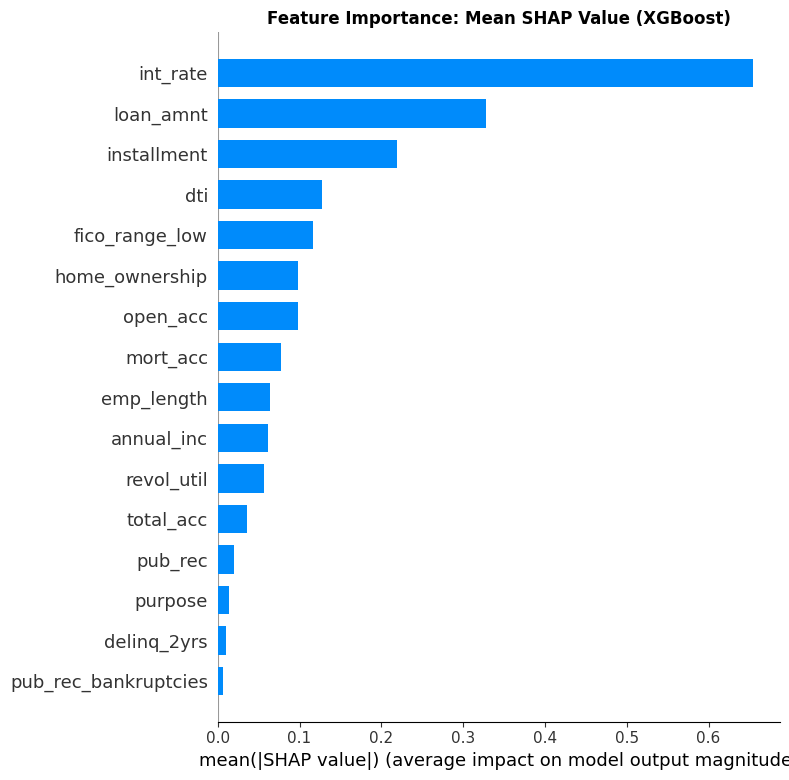

In [55]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_sample, plot_type='bar', show=False)
plt.title('Feature Importance: Mean SHAP Value (XGBoost)', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_importance.png', bbox_inches='tight', dpi=150)
plt.show()

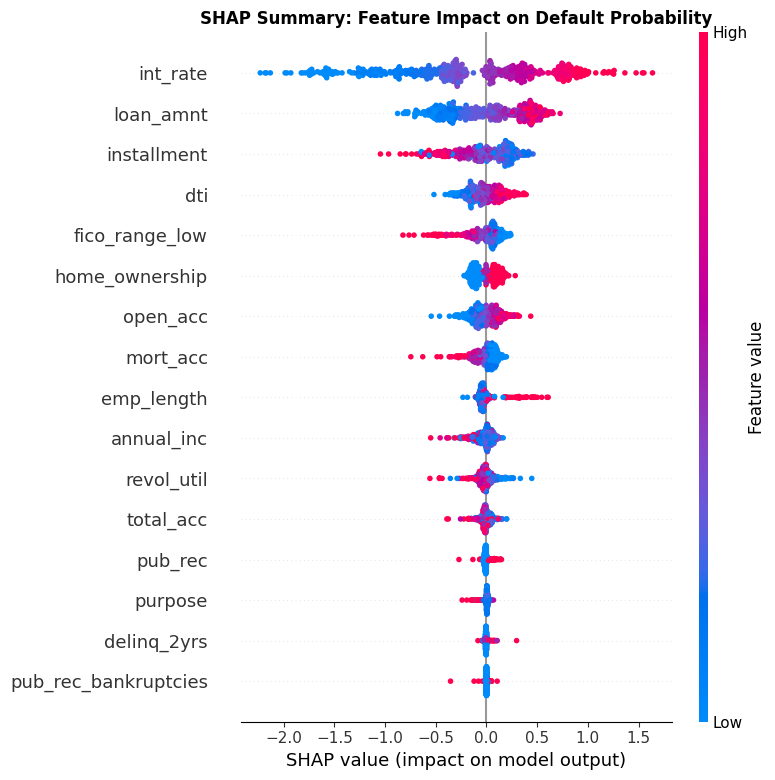

In [56]:
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_sample, show=False)
plt.title('SHAP Summary: Feature Impact on Default Probability', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', bbox_inches='tight', dpi=150)
plt.show()
